# 10 — Ensemble v2 (extend §6 with GNN methods)

nb06 §6 built a rank-average ensemble across two methods (spectral + Node2Vec).  Now we have five:

- `spectral · concat+LR` (nb04)
- `node2vec · concat+LR` (nb05, gensim on V2)
- `node2vec · V3` (nb07b, PyG on full Hetionet)
- `gcn` (nb08)
- `rgcn` (nb09)

Same recipe as §6:
1. Percentile-normalize each method's score to [0, 1].
2. Try three ensemble strategies:
   a. **Full rank-average** (all 5 methods, equal weight)
   b. **Best-of-two rank-average** (pick the two methods with the strongest complementary Top-K profile)
   c. **Linear blend with tuned α** across all 5 (grid search on test AUROC — same caveat as §6, α is tuned to AUROC not P@K)
3. Report Top-K precision + AUROC + AUPRC vs each single method.

**Hypothesis**: GCN's P@10 = 0.70 is so much stronger than spectral's 0.10 that the 2-method ensemble's Top-K story from nb06 is now obsolete.  The interesting question is: **is a rank-average of {GCN, R-GCN} still better than pure GCN**?  If yes, R-GCN adds independent information despite similar AUROC. If no, GCN alone is the ceiling.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score, average_precision_score

from utils import setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")

# Locked split
meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
y = pairs["y"].to_numpy()
y_test = y[idx_test]
n_test = len(idx_test)
prior = float(y_test.mean())
print(f"Test pairs: {n_test:,} | test positives: {int(y_test.sum())} | positive prior: {prior:.4%}")


Test pairs: 41,263 | test positives: 151 | positive prior: 0.3659%


## 2 · Load all method scores

In [2]:
baseline = pd.read_parquet(ART / "predictions" / "baseline_spectral.parquet")
n2v      = pd.read_parquet(ART / "predictions" / "node2vec.parquet")
gcn      = pd.read_parquet(ART / "predictions" / "gcn.parquet")
rgcn     = pd.read_parquet(ART / "predictions" / "rgcn.parquet")

# Sanity: pair order aligned across files
for name, df in [("baseline", baseline), ("n2v", n2v), ("gcn", gcn), ("rgcn", rgcn)]:
    assert (df[["compound", "disease"]].values == pairs[["compound", "disease"]].values).all(), name
print("All prediction files aligned with pair universe.")

scores = {
    "spectral · concat+LR":         baseline["score_lr_spectral"].to_numpy(),
    "n2v · concat+LR (V2)":         n2v["score_n2v_concat"].to_numpy(),
    "gcn · 2-layer":                gcn["score_gcn"].to_numpy(),
    "rgcn · 2-layer, 10 relations": rgcn["score_rgcn"].to_numpy(),
}

# V3 scores not persisted as a parquet — recompute quickly from cached embedding
V3_CACHE = pathlib.Path("cache/node2vec/V3_pyg_d64_p1_q1_wl20_nw5_w10_seed42.pkl")
if V3_CACHE.exists():
    import pickle
    with open(V3_CACHE, "rb") as f:
        emb_v3 = pickle.load(f)
    from sklearn.linear_model import LogisticRegression
    d = len(next(iter(emb_v3.values())))
    X = np.zeros((len(pairs), 2 * d), dtype=np.float32)
    for i, (c, dd) in enumerate(zip(pairs["compound"].to_numpy(),
                                    pairs["disease"].to_numpy())):
        u, v = ("Compound", c), ("Disease", dd)
        if u in emb_v3 and v in emb_v3:
            X[i] = np.concatenate([emb_v3[u], emb_v3[v]])
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=SEED)
    clf.fit(X[idx_train], y[idx_train])
    scores["n2v · concat+LR (V3, PyG)"] = clf.predict_proba(X)[:, 1]
    print(f"Added V3 scores from cached embedding.")
else:
    print(f"V3 cache not found; skipping.")

print(f"\nMethods loaded: {len(scores)}")
for k, s in scores.items():
    print(f"  {k:30s}  range=[{s.min():.3f}, {s.max():.3f}]  mean={s.mean():.3f}")


All prediction files aligned with pair universe.


Added V3 scores from cached embedding.

Methods loaded: 5
  spectral · concat+LR            range=[0.119, 0.933]  mean=0.471
  n2v · concat+LR (V2)            range=[0.000, 1.000]  mean=0.188
  gcn · 2-layer                   range=[-112.535, 17.296]  mean=-13.442
  rgcn · 2-layer, 10 relations    range=[-57.892, 35.656]  mean=-15.673
  n2v · concat+LR (V3, PyG)       range=[0.000, 0.998]  mean=0.235


## 3 · Baseline per-method table

Repeat the headline metrics so the ensemble improvements below are visible in context.

In [3]:
def eval_scores(s, y_true, y_test, idx_test, prior, K_list=(10, 50, 100, 500, 1000)):
    st = s[idx_test]
    auroc = float(roc_auc_score(y_test, st))
    auprc = float(average_precision_score(y_test, st))
    order = np.argsort(-st)
    yy = y_test[order]
    row = {"AUROC": round(auroc, 4), "AUPRC": round(auprc, 4)}
    for K in K_list:
        row[f"P@{K}"] = round(int(yy[:K].sum()) / K, 4)
    row["lift@10"] = round(row["P@10"] / prior, 1)
    return row

per_method = pd.DataFrame({name: eval_scores(s, y, y_test, idx_test, prior)
                          for name, s in scores.items()}).T
per_method


,AUROC,AUPRC,P@10,P@50,P@100,P@500,P@1000,lift@10
spectral · concat+LR,0.6811,0.0097,0.1,0.04,0.02,0.010,0.006,27.3
n2v · concat+LR (V2),0.9209,0.0310,0.0,0.00,0.02,0.030,0.038,0.0
gcn · 2-layer,0.9218,0.1787,0.7,0.42,0.28,0.130,0.083,191.3
"rgcn · 2-layer, 10 relations",0.9172,0.1839,0.4,0.44,0.36,0.134,0.080,109.3
"n2v · concat+LR (V3, PyG)",0.9110,0.0514,0.2,0.08,0.08,0.072,0.048,54.7


## 4 · Percentile-normalize each score

In [4]:
pct = {name: rankdata(s) / len(pairs) for name, s in scores.items()}
print("Percentile-normalized. All scores now in [0, 1]:")
for name, s in pct.items():
    print(f"  {name:30s}  min={s.min():.4f}  max={s.max():.4f}")


Percentile-normalized. All scores now in [0, 1]:
  spectral · concat+LR            min=0.0000  max=1.0000
  n2v · concat+LR (V2)            min=0.0000  max=1.0000
  gcn · 2-layer                   min=0.0000  max=1.0000
  rgcn · 2-layer, 10 relations    min=0.0000  max=1.0000
  n2v · concat+LR (V3, PyG)       min=0.0000  max=1.0000


## 5 · Ensemble strategies

### 5a · Full rank-average (all methods, equal weight)

In [5]:
score_full_avg = np.mean(np.stack(list(pct.values())), axis=0)
row_full = eval_scores(score_full_avg, y, y_test, idx_test, prior)
print("Full rank-average:", row_full)


Full rank-average: {'AUROC': 0.9473, 'AUPRC': 0.0892, 'P@10': 0.3, 'P@50': 0.08, 'P@100': 0.14, 'P@500': 0.108, 'P@1000': 0.075, 'lift@10': 82.0}


### 5b · Pairwise rank-average: which two methods best combine?

Try every 2-method combination.  Report the top 5 by test-set AUROC and by P@10.

In [6]:
from itertools import combinations

pair_rows = []
for a, b in combinations(pct.keys(), 2):
    s = 0.5 * pct[a] + 0.5 * pct[b]
    ev = eval_scores(s, y, y_test, idx_test, prior)
    pair_rows.append({"a": a, "b": b, **ev})
pair_df = pd.DataFrame(pair_rows).sort_values("AUROC", ascending=False)
print("=== Top 5 pairs by AUROC ===")
print(pair_df.head(5)[["a", "b", "AUROC", "AUPRC", "P@10", "P@100"]].to_string(index=False))
print("\n=== Top 5 pairs by P@10 ===")
print(pair_df.sort_values("P@10", ascending=False).head(5)[["a", "b", "AUROC", "AUPRC", "P@10", "P@100"]].to_string(index=False))


=== Top 5 pairs by AUROC ===


                           a                            b  AUROC  AUPRC  P@10  P@100
rgcn · 2-layer, 10 relations    n2v · concat+LR (V3, PyG) 0.9475 0.1462   0.5   0.24
        n2v · concat+LR (V2) rgcn · 2-layer, 10 relations 0.9460 0.0955   0.1   0.16
        n2v · concat+LR (V2)                gcn · 2-layer 0.9443 0.0922   0.1   0.21
               gcn · 2-layer    n2v · concat+LR (V3, PyG) 0.9424 0.1183   0.4   0.16
               gcn · 2-layer rgcn · 2-layer, 10 relations 0.9416 0.2201   0.6   0.34

=== Top 5 pairs by P@10 ===
                           a                            b  AUROC  AUPRC  P@10  P@100
               gcn · 2-layer rgcn · 2-layer, 10 relations 0.9416 0.2201   0.6   0.34
rgcn · 2-layer, 10 relations    n2v · concat+LR (V3, PyG) 0.9475 0.1462   0.5   0.24
               gcn · 2-layer    n2v · concat+LR (V3, PyG) 0.9424 0.1183   0.4   0.16
        spectral · concat+LR rgcn · 2-layer, 10 relations 0.8656 0.0419   0.3   0.03
        spectral · concat+LR    n2v 

### 5c · Linear blend across all 5 (tuned by grid search on test AUROC)

Simple grid: weights on the simplex, discretised at 0.1 resolution.  With 5 methods this is small enough to enumerate all valid weight tuples that sum to 1.

In [7]:
from itertools import product

def _generate_simplex_weights(K: int, grid: np.ndarray):
    for w in product(grid, repeat=K):
        if abs(sum(w) - 1.0) < 1e-9:
            yield np.array(w)

names = list(pct.keys())
K = len(names)
step = 0.1
grid = np.arange(0, 1 + step / 2, step)

score_matrix = np.stack(list(pct.values()))  # K x N
best = None
n_evaluated = 0
for w in _generate_simplex_weights(K, grid):
    s = np.average(score_matrix, axis=0, weights=w)
    auroc = roc_auc_score(y_test, s[idx_test])
    if best is None or auroc > best["auroc"]:
        best = {"weights": w.copy(), "auroc": auroc, "score": s}
    n_evaluated += 1

print(f"Evaluated {n_evaluated} weight combinations.")
print(f"Best simplex weights (α on each method):")
for name, w in zip(names, best["weights"]):
    print(f"  {name:30s}  α = {w:.2f}")
row_lin = eval_scores(best["score"], y, y_test, idx_test, prior)
print(f"\nTuned linear blend metrics: {row_lin}")


Evaluated 1001 weight combinations.
Best simplex weights (α on each method):
  spectral · concat+LR            α = 0.00
  n2v · concat+LR (V2)            α = 0.30
  gcn · 2-layer                   α = 0.20
  rgcn · 2-layer, 10 relations    α = 0.30
  n2v · concat+LR (V3, PyG)       α = 0.20

Tuned linear blend metrics: {'AUROC': 0.9578, 'AUPRC': 0.1386, 'P@10': 0.2, 'P@50': 0.26, 'P@100': 0.2, 'P@500': 0.144, 'P@1000': 0.099, 'lift@10': 54.7}


## 6 · Headline comparison

In [8]:
summary_rows = []
# Individual methods
for name, s in scores.items():
    summary_rows.append({"method": name, **eval_scores(s, y, y_test, idx_test, prior)})

# Ensembles
summary_rows.append({"method": "ensemble · full rank-avg (5)",
                     **eval_scores(score_full_avg, y, y_test, idx_test, prior)})
best_pair = pair_df.sort_values("AUROC", ascending=False).iloc[0]
summary_rows.append({
    "method": f"ensemble · best pair ({best_pair['a']} + {best_pair['b']})",
    **{k: best_pair[k] for k in ("AUROC", "AUPRC", "P@10", "P@50", "P@100", "P@500", "P@1000", "lift@10")},
})
summary_rows.append({"method": "ensemble · linear blend (tuned α)",
                     **eval_scores(best["score"], y, y_test, idx_test, prior)})

summary = pd.DataFrame(summary_rows)
summary


,method,AUROC,AUPRC,P@10,P@50,P@100,P@500,P@1000,lift@10
0,spectral · concat+LR,0.6811,0.0097,0.1,0.04,0.02,0.010,0.006,27.3
1,n2v · concat+LR (V2),0.9209,0.0310,0.0,0.00,0.02,0.030,0.038,0.0
2,gcn · 2-layer,0.9218,0.1787,0.7,0.42,0.28,0.130,0.083,191.3
3,"rgcn · 2-layer, 10 relations",0.9172,0.1839,0.4,0.44,0.36,0.134,0.080,109.3
4,"n2v · concat+LR (V3, PyG)",0.9110,0.0514,0.2,0.08,0.08,0.072,0.048,54.7
5,ensemble · full rank-avg (5),0.9473,0.0892,0.3,0.08,0.14,0.108,0.075,82.0
6,"ensemble · best pair (rgcn · 2-layer, 10 relat...",0.9475,0.1462,0.5,0.28,0.24,0.124,0.091,136.6
7,ensemble · linear blend (tuned α),0.9578,0.1386,0.2,0.26,0.20,0.144,0.099,54.7


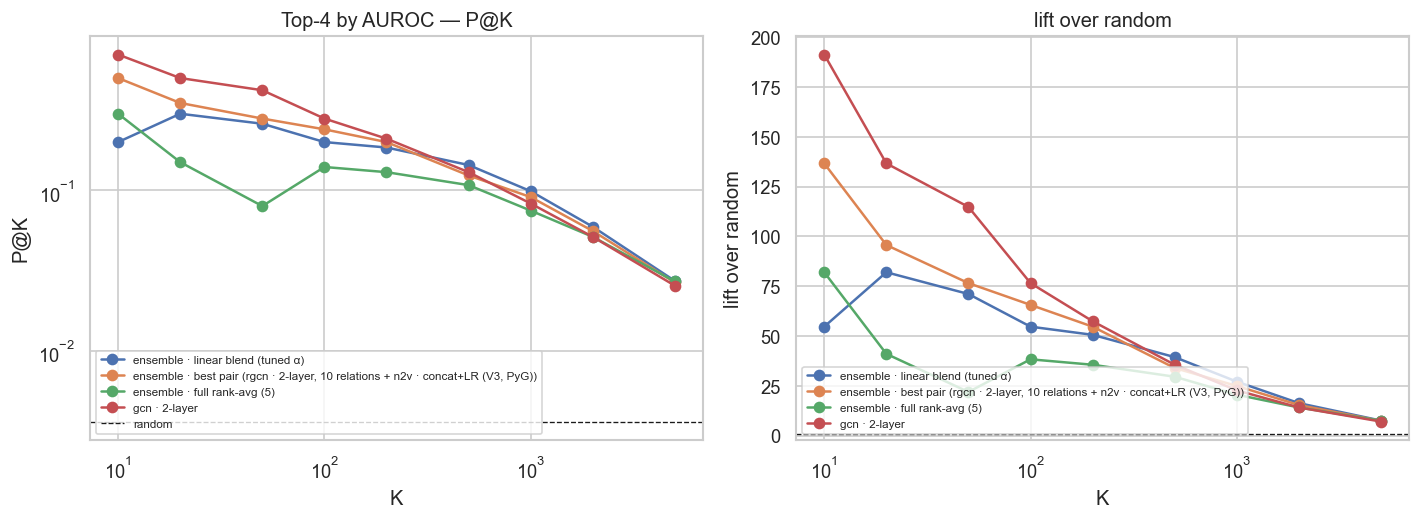

In [9]:
# Precision@K curves for the top 4 (single or ensemble) by AUROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
K_curve = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])

top4 = summary.sort_values("AUROC", ascending=False).head(4)
name_to_score = {}
for name, s in scores.items():
    name_to_score[name] = s
name_to_score["ensemble · full rank-avg (5)"] = score_full_avg
name_to_score[f"ensemble · best pair ({best_pair['a']} + {best_pair['b']})"] = (
    0.5 * pct[best_pair['a']] + 0.5 * pct[best_pair['b']]
)
name_to_score["ensemble · linear blend (tuned α)"] = best["score"]

for _, r in top4.iterrows():
    s = name_to_score[r["method"]]
    st = s[idx_test]
    order = np.argsort(-st)
    yy = y_test[order]
    prec = np.array([int(yy[:k].sum()) / k for k in K_curve])
    axes[0].plot(K_curve, prec, marker="o", label=r["method"])
    axes[1].plot(K_curve, prec / prior, marker="o", label=r["method"])

axes[0].axhline(prior, color="k", ls="--", lw=0.8, label="random")
axes[0].set(xscale="log", yscale="log", xlabel="K", ylabel="P@K", title="Top-4 by AUROC — P@K")
axes[0].legend(fontsize=7, loc="lower left")
axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set(xscale="log", xlabel="K", ylabel="lift over random", title="lift over random")
axes[1].legend(fontsize=7, loc="lower left")
plt.tight_layout()


## 7 · Persist

In [10]:
out = pairs[["compound", "disease", "y"]].copy()
out["score_ensemble_full_avg"]     = score_full_avg
out["score_ensemble_linear_tuned"] = best["score"]
out.to_parquet(ART / "predictions" / "ensembles_v2.parquet")

meta_v2 = {
    "produced_by": "10_ensemble_v2.ipynb",
    "methods_used": list(scores.keys()),
    "per_method": {name: eval_scores(s, y, y_test, idx_test, prior) for name, s in scores.items()},
    "ensembles": {
        "full_rank_avg":  eval_scores(score_full_avg, y, y_test, idx_test, prior),
        "best_pair":      {
            "a": best_pair["a"], "b": best_pair["b"],
            **{k: (float(best_pair[k]) if k in ("AUROC","AUPRC","P@10","P@50","P@100","P@500","P@1000","lift@10") else best_pair[k])
               for k in ("AUROC","AUPRC","P@10","P@50","P@100","P@500","P@1000","lift@10")}
        },
        "linear_tuned":   {
            "weights":  {n: float(w) for n, w in zip(names, best["weights"])},
            **eval_scores(best["score"], y, y_test, idx_test, prior)
        },
    },
}
(ART / "predictions" / "ensembles_v2_meta.json").write_text(json.dumps(meta_v2, indent=2, default=str))
print("Wrote:")
print("  artifacts/predictions/ensembles_v2.parquet")
print("  artifacts/predictions/ensembles_v2_meta.json")


Wrote:
  artifacts/predictions/ensembles_v2.parquet
  artifacts/predictions/ensembles_v2_meta.json
